In [40]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import seaborn as sns
import matplotlib.pyplot as plt
print('Libraries imported')

Libraries imported


In [41]:
df=pd.read_csv('./diabetes.csv')
df.info

<bound method DataFrame.info of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   5

In [42]:
df.shape

(768, 9)

In [43]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.isnull().sum().sum()

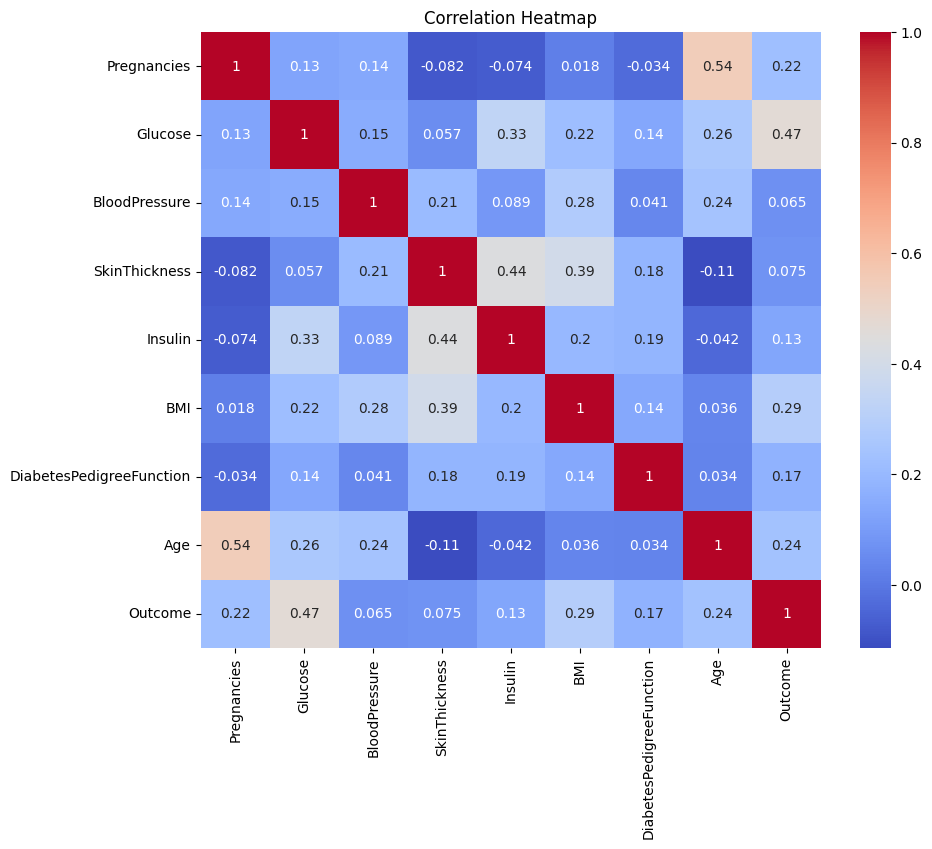

In [52]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [45]:
X=df.drop('Outcome', axis=1)
y=df['Outcome']



In [46]:
X_train, X_test, y_train, y_test= train_test_split(
    X,y,test_size=0.2, random_state=42
)

print(f'Training samples: {X_train.shape}')
print(f' Testing samples: {X_test.shape}')

Training samples: (614, 8)
 Testing samples: (154, 8)


In [47]:
scalar=StandardScaler()
X_train=scalar.fit_transform(X_train)
X_test=scalar.fit_transform(X_test)

In [48]:
model=LogisticRegression()
model.fit(X_train,y_train)
print('Model trained')

Model trained


In [49]:
y_pred=model.predict(X_test)
print(f'Accuracy score: {accuracy_score(y_test,y_pred)}')

Accuracy score: 0.7857142857142857


In [50]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[86 13]
 [20 35]]


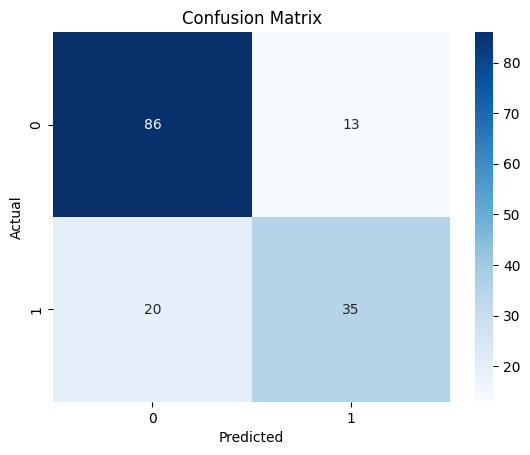

In [51]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()